# LLM-as-Judge Pilot Validation

Validates the tone-frustration fit rubric on 30 pilot pairs before scaling to 1,800 API calls.

**Flow:**
1. Load `data/pilot_30.csv`
2. Generate GPT-4o responses for all 30 complaints
3. Score all 60 responses (30 human + 30 GPT-4o) with the GPT-4o judge
4. Export `data/pilot_scores.csv` for human raters to fill in
5. Compute Cohen's κ → GO / NO-GO on κ ≥ 0.60

In [24]:
import os
import time
import pandas as pd
from openai import OpenAI
from sklearn.metrics import cohen_kappa_score
from dotenv import load_dotenv

load_dotenv("../.env")
client = OpenAI(api_key=os.environ["OPEN_AI_API_KEY"])
print("OpenAI client ready")

OpenAI client ready


In [25]:
pilot = pd.read_csv("./data/pilot_30.csv", engine="python")
print(f"Loaded {len(pilot)} pilot pairs")
pilot[["pair_id", "domain", "fis_bin", "customer_text", "agent_text"]].head()

Loaded 30 pilot pairs


,pair_id,domain,fis_bin,customer_text,agent_text
0,1991690,airline,high,@Delta yeah fuck delta and their shitty custom...,@464554 We're sorry that this has been your ex...
1,716032,technology,high,@AmazonHelp I received a wrong Amazon Prime or...,"@291339 Oh no, we're sorry to see this! Please..."
2,2546118,airline,high,@AmericanAir what is happening with AA 721 htt...,@723675 We've received your DM and will meet y...
3,2752725,technology,moderate,@AppleSupport ever since I updated to iOS 11.1...,@770596 We'd be happy to look into this with y...
4,2146634,technology,moderate,@AppleSupport please fix this I️ bullshjt,@631026 Here’s what you can do to work around...


In [26]:
SYSTEM_PROMPT = (
    "You are a customer support agent. "
    "Respond to the following customer message in one to three sentences."
)

def generate_response(complaint: str, retries: int = 3) -> str:
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": complaint},
                ],
                temperature=0,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)

pilot["gpt4o_response"] = [generate_response(t) for t in pilot["customer_text"]]
pilot[["pair_id", "customer_text", "gpt4o_response"]].head()

,pair_id,customer_text,gpt4o_response
0,1991690,@Delta yeah fuck delta and their shitty custom...,I'm sorry to hear about your experience. Pleas...
1,716032,@AmazonHelp I received a wrong Amazon Prime or...,I'm sorry to hear about the mix-up with your o...
2,2546118,@AmericanAir what is happening with AA 721 htt...,I'm sorry for any inconvenience you're experie...
3,2752725,@AppleSupport ever since I updated to iOS 11.1...,I'm sorry to hear about the issues you're expe...
4,2146634,@AppleSupport please fix this I️ bullshjt,I'm sorry to hear you're having trouble. Could...


In [27]:
JUDGE_RUBRIC = """\
You are evaluating a customer support response for TONE-FRUSTRATION FIT: \
does the tone of the response appropriately match the emotional register of the complaint?

Score using this 3-point scale:

1 = MISMATCHED
   The response tone is clearly wrong for the situation.
   Examples:
   - Complaint: "@116072 worst customer service I ever received , even tho I love ur product. #disappointed"
     Response:  "@440018 Hello Sue, I would be more than happy to assist you. Please send me a DM. -Katie"
     Why: Customer uses strong words, but agent sounds indifferent and does not seem to want more context about the issue.
   - Complaint: "@SouthwestAir paid for early boarding today while traveling with wife &amp; infant only to be moved to back of plane by crew last minute thanks!"
     Response:  "@709064 Hi, Matt. Did they move you because of a weight and balance concern? ^LJ"
     Why: No compassion words provided to let customers know company cares about them. Plus the overweight question is too private to be asked publicly.

2 = PARTIALLY MATCHED
   The response acknowledges the issue but the tone is noticeably off — either too warm, too cold, or too generic.
   Examples:
   - Complaint: "The one app I DIDNT update after the new iOS was Twitter and it’s the only one that opens/doesn’t crash. @AppleSupport  FIX IT"
     Response:  "@410910 Let's help take a closer look. Does this seem to persist after rebooting the device? Which apps are most in use when you experience these issues? Are all your apps up to date in the App Store?"
     Why: Good on diving straight to the solution, but could be better if talk with more compassion about the issues in the opening.
   - Complaint: "It would be great if @jetblue would let the passengers know why there is an hour delay. Crew just chatting away."
     Response:  "@316974 Sorry to hear about the delay, Chuck. What's your flight number? The reason might have not been relayed to them just yet."
     Why: Customer is not very frustrated, and is complaining about the delay. The agent identifies the wrong issue and over apologizes. But they did provide valid response in the end.

3 = WELL MATCHED
   The tone is appropriately calibrated — warm and urgent when the customer is upset, \
light and helpful when the inquiry is casual.
   Examples:
   - Complaint: "@115913 @TMobileHelp can anyone help me figure out the mystery of the missing iPhone 7+? Returned a phone, now it's missing. #frustrated"
     Response:  "@728649 @115913 Hi! That's certainly not what I want for you at all and would love to get to the bottom of this. DM us https://t.co/3sF8qpf2nx *AlissaFast"
     Why: Matches the customer's frustration when losing their high value properties, because the agent uses strong words like certainly and at all.s
   - Complaint: "@115714  just picked up a new iPhone 8 from y'all!! Can I get a follow back?!"
     Response:  "@323592 Awesome! :) How do you like your new device? We tried hitting that Follow icon on our end, however, we'll need you to hit it for us! -AJS"
     Why: Delightful tone matches comment that express satisfaction.

---

Complaint: {complaint}
Response: {response}

Reply with a single integer (1, 2, or 3) and nothing else.\
"""

def judge_score(complaint: str, response: str, retries: int = 3) -> int:
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": JUDGE_RUBRIC.format(
                    complaint=complaint, response=response
                )}],
                temperature=0,
            )
            return int(resp.choices[0].message.content.strip())
        except Exception as e:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)

print("Judge rubric (3-point scale with examples) defined")

Judge rubric (3-point scale with examples) defined


In [28]:
pilot["judge_score_human"] = [
    judge_score(c, r) for c, r in zip(pilot["customer_text"], pilot["agent_text"])
]
pilot["judge_score_gpt4o"] = [
    judge_score(c, r) for c, r in zip(pilot["customer_text"], pilot["gpt4o_response"])
]

pilot[["pair_id", "fis_bin", "judge_score_human", "judge_score_gpt4o"]].head(10)

,pair_id,fis_bin,judge_score_human,judge_score_gpt4o
0,1991690,high,1,2
1,716032,high,3,2
2,2546118,high,2,2
3,2752725,moderate,2,3
4,2146634,moderate,2,2
5,2697967,high,2,2
6,346371,moderate,2,2
7,488657,low,2,2
8,551009,moderate,1,2
9,1910493,high,1,1


In [29]:
export = pilot[[
    "pair_id", "domain", "fis_bin",
    "customer_text", "agent_text",
    "judge_score_human",
    "judge_score_gpt4o",
]].copy()
export["human_rater_1"] = ""  # fill in manually
export["human_rater_2"] = ""  # fill in manually

export.to_csv("./data/pilot_scores.csv", index=False)
print("Exported ./data/pilot_scores.csv")
print("Next: fill in human_rater_1 and human_rater_2 columns, then run Cell 7")

Exported ./data/pilot_scores.csv
Next: fill in human_rater_1 and human_rater_2 columns, then run Cell 7


In [33]:
rated = pd.read_csv("./data/pilot_scores.csv")
rated = rated.dropna(subset=["human_rater_1", "human_rater_2"])
rated = rated[rated["human_rater_1"].astype(str).str.strip() != ""]
rated["human_rater_1"] = rated["human_rater_1"].astype(int)
rated["human_rater_2"] = rated["human_rater_2"].astype(int)

kappa_r1 = cohen_kappa_score(rated["judge_score_human"], rated["human_rater_1"])
kappa_r2 = cohen_kappa_score(rated["judge_score_human"], rated["human_rater_2"])

print(f"Rows with human scores: {len(rated)}")
print(f"Cohen's κ (judge vs rater 1): {kappa_r1:.3f}")
print(f"Cohen's κ (judge vs rater 2): {kappa_r2:.3f}")
print()
if kappa_r1 >= 0.60 and kappa_r2 >= 0.60:
    print("GO — proceed to full 600-instance run")
else:
    print("NO-GO — revise rubric and re-pilot")

Rows with human scores: 30
Cohen's κ (judge vs rater 1): 0.622
Cohen's κ (judge vs rater 2): 0.622

GO — proceed to full 600-instance run


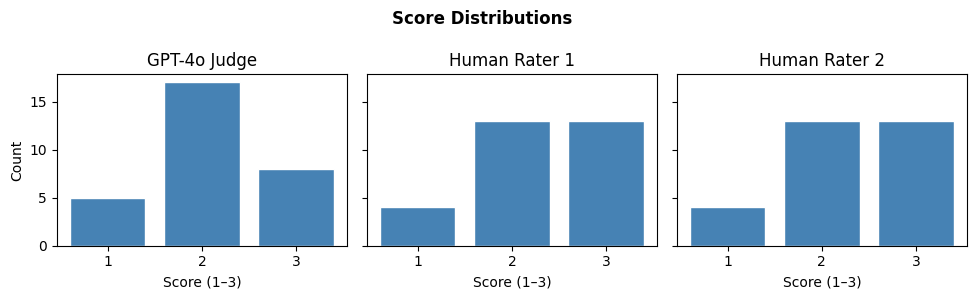

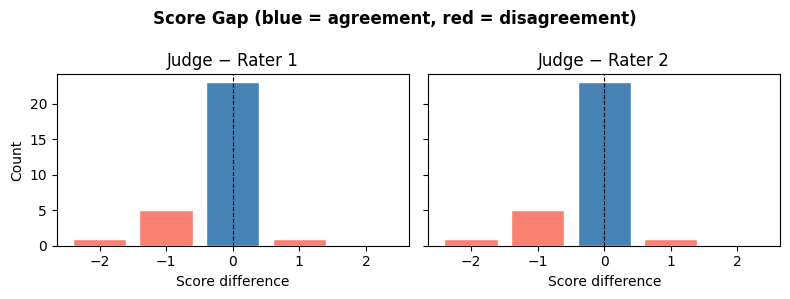

=== Top 5 most contested pairs ===

pair_id=1991690 | fis_bin=high | judge=1 rater1=3 rater2=3
  complaint : @Delta yeah fuck delta and their shitty customer service
  response  : @464554 We're sorry that this has been your experience. Please don't hesitate to reach out to us if additional assistanc

pair_id=2697967 | fis_bin=high | judge=2 rater1=3 rater2=3
  complaint : @117634 - Tried typing this on a shitty Fire, didn't work, just like you guys. I bought &amp; downloaded a book, was on 
  response  : @698687 I'm terribly sorry you are having trouble with your book. What type of error message appears?
^AV

pair_id=1164835 | fis_bin=low | judge=2 rater1=3 rater2=3
  complaint : @AmericanAir help my family get to St. Louis by tonight!!!!!!!!! #replytweet
  response  : @394008 We're sorry to hear that your family's flight is delayed. Please follow and DM your record locator and we'll che

pair_id=316766 | fis_bin=low | judge=2 rater1=3 rater2=3
  complaint : @British_Airways Hi, I'm pr

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

scores = [1, 2, 3]

# --- Score distributions ---
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, col, label in zip(axes,
                           ["judge_score_human", "human_rater_1", "human_rater_2"],
                           ["GPT-4o Judge", "Human Rater 1", "Human Rater 2"]):
    counts = rated[col].value_counts().reindex(scores, fill_value=0)
    ax.bar(scores, counts, color="steelblue", edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("Score (1–3)")
    ax.set_xticks(scores)
axes[0].set_ylabel("Count")
fig.suptitle("Score Distributions", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Gap distributions ---
rated["gap_r1"] = rated["judge_score_human"] - rated["human_rater_1"]
rated["gap_r2"] = rated["judge_score_human"] - rated["human_rater_2"]

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax, col, label in zip(axes,
                           ["gap_r1", "gap_r2"],
                           ["Judge − Rater 1", "Judge − Rater 2"]):
    gaps = range(-2, 3)
    counts = rated[col].value_counts().reindex(gaps, fill_value=0)
    colors = ["salmon" if g != 0 else "steelblue" for g in gaps]
    ax.bar(gaps, counts, color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("Score difference")
    ax.set_xticks(list(gaps))
axes[0].set_ylabel("Count")
fig.suptitle("Score Gap (blue = agreement, red = disagreement)", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Worst disagreements ---
rated["max_gap"] = rated[["gap_r1", "gap_r2"]].abs().max(axis=1)
worst = rated.nlargest(5, "max_gap")[
    ["pair_id", "fis_bin", "customer_text", "agent_text",
     "judge_score_human", "human_rater_1", "human_rater_2", "max_gap"]
]
print("=== Top 5 most contested pairs ===")
for _, row in worst.iterrows():
    print(f"\npair_id={row.pair_id} | fis_bin={row.fis_bin} | "
          f"judge={row.judge_score_human} rater1={row.human_rater_1} rater2={row.human_rater_2}")
    print(f"  complaint : {str(row.customer_text)[:120]}")
    print(f"  response  : {str(row.agent_text)[:120]}")